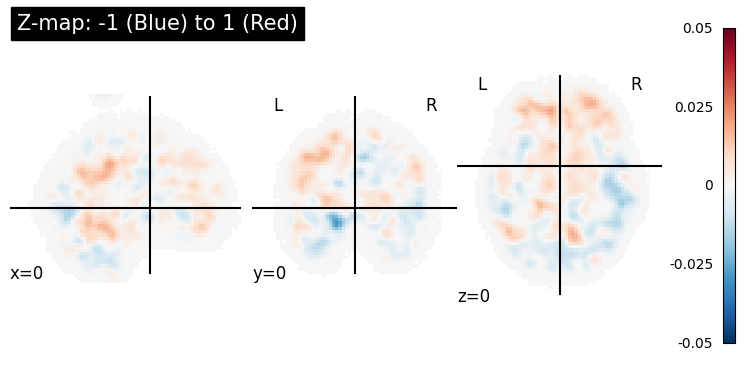

In [4]:
from nilearn import plotting
import matplotlib.pyplot as plt

# 您的 .nii 檔案路徑
nii_file = '/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/ZMAP/8mm/roi1_HIP_R/ses01min02/MEAN_02min01.nii' 

# ==========================================
# 方法一：產生靜態 3D 切面圖 (適合放入論文)
# ==========================================
# 使用 plot_stat_map 會自動將您的圖疊加在標準 MNI152 灰階大腦上
display = plotting.plot_stat_map(
    stat_map_img=nii_file,
    display_mode='ortho',     # 顯示 X, Y, Z 三個正交切面
    cmap='RdBu_r',            # RdBu_r: 負值(藍色) -> 0(白色) -> 正值(紅色)
    vmax=0.05,                 # 設定最大值為 1 (配合 nilearn 預設對稱，最小值自動變 -1)
    symmetric_cbar=True,      # 強制色階以 0 為中心對稱 (-1 到 1)
    title="Z-map: -1 (Blue) to 1 (Red)",
    cut_coords=(0, 0, 0)      # 可選：指定十字游標的中心座標，或刪除此行讓程式自動抓極值
)

# # 儲存成高畫質圖片
# display.savefig('static_brain_map.png', dpi=300)
# print("✅ 靜態圖已儲存為 static_brain_map.png")

# # ==========================================
# # 方法二：產生互動式 3D 檢視器 (在瀏覽器中開啟)
# # ==========================================
# html_view = plotting.view_img(
#     stat_map_img=nii_file,
#     cmap='RdBu_r',            # 同樣使用藍到紅的色階
#     vmax=1.0,                 # 設定最大值為 1
#     symmetric_cmap=True,      # 強制對稱
#     threshold=0.2,            # 【實用技巧】將絕對值低於 0.2 的數值變透明，避免背景充滿雜訊
#     title="Interactive Z-map",
#     black_bg=True             # 黑色背景能讓紅藍訊號更跳脫
# )

# # 將互動視窗存成 HTML 網頁檔
# html_view.save_as_html('interactive_brain_map.html')
# print("✅ 互動圖已儲存為 interactive_brain_map.html (請用 Chrome/Edge 開啟)")

# # 如果您是在 Jupyter Notebook 中執行，可以直接顯示：
# # html_view

ValueError: could not convert string to float: '95%'

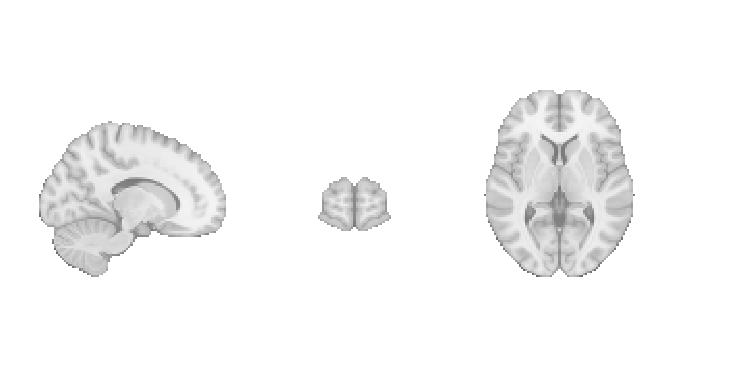

In [17]:
from nilearn import plotting
import matplotlib.pyplot as plt


nii_file = '/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/ZMAP/8mm/roi1_HIP_R/ses01min02/MEAN_02min01.nii' 
# 視覺化剛剛算出來的 FC Map
# 假設你已經用 mean_img 算出了 3d_mean_epi 當作底圖 (參考先前的腳本)
plotting.plot_stat_map(
    stat_map_img=nii_file, 
    # bg_img=d_mean_epi,     # 你的 3D EPI 平均底圖
    threshold="95%",          # 視覺化門檻：只顯示 Fisher Z 值大於 0.2 或小於 -0.2 的強連結區域
    title="Seed-to-Voxel FC (Fisher Z > 0.3)",
    display_mode='ortho',
    cut_coords=(-15,66,3),   # 你可以改成你海馬迴 Seed 的大約 MNI 座標
    cmap='cold_hot'
)

plt.show()

自動計算出的閾值為: 0.0155


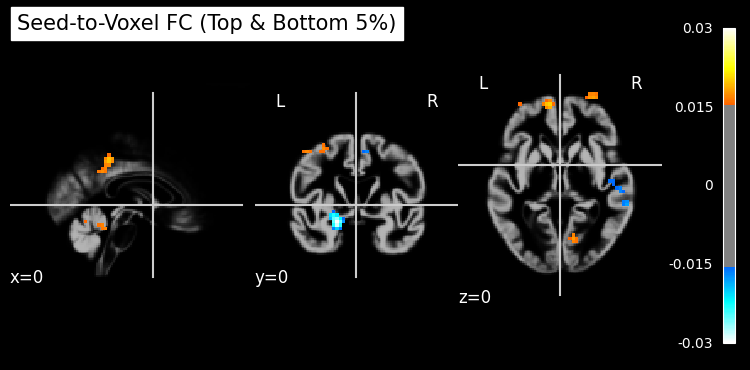

In [25]:
import numpy as np
from nilearn import image, plotting
import matplotlib.pyplot as plt


nii_file = '/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/ZMAP/8mm/roi1_HIP_R/ses01min02/MEAN_02min01.nii' 

bg_T1_4D = "/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/SST/Template_6.nii"

bg_T1_3D = image.index_img(bg_T1_4D, 0)


# 1. 將影像讀取進來
img = image.load_img(nii_file)
data = img.get_fdata()

# 2. 過濾掉背景 (0) 與 NaN，只保留大腦內有意義的數值
valid_data = data[np.isfinite(data) & (data != 0)]

# 3. 數學運算：算出絕對值的「第 90 百分位數」
# 這代表只抓出數值最極端（不管是正還是負）的前 10%
threshold_value = np.percentile(np.abs(valid_data), 99)

print(f"自動計算出的閾值為: {threshold_value:.4f}")

# 4. 畫圖 (把算出來的浮點數 threshold_value 餵給它)
display = plotting.plot_stat_map(
    stat_map_img=img,
    threshold=threshold_value,  # <--- 這裡變成傳入純數字了，絕對不會報錯
    bg_img=bg_T1_3D,   
    title=f"Seed-to-Voxel FC (Top & Bottom 5%)",
    display_mode='ortho',
    cut_coords=(0,0,0), 
    cmap='cold_hot'
)

plt.show()